1. MONTHLY SEASONALITY SUMMARY (2010–2016)
Month_Name  Mean_Price  Median_Price  Std_Dev  Min_Price  Max_Price
       Jan      487.74         420.0   204.19      102.0      820.0
       Feb      401.78         390.0   171.43      102.0      820.0
       Mar      209.20         190.0    91.35       82.0      620.0
       Apr      251.99         230.0   125.71       82.0      820.0
       May      251.33         210.0   146.57       62.0      820.0
       Jun      148.01         130.0    80.19       50.0      720.0
       Jul      336.15         250.0   232.36       82.0      820.0
       Aug      391.90         370.0   215.29       70.0      820.0
       Sep      352.45         310.0   210.93       50.0      820.0
       Oct      447.63         405.0   248.05       65.0      820.0
       Nov      458.52         405.0   199.40      150.0      820.0
       Dec      577.40         520.0   199.73      210.0      820.0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_25620\3878540712.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


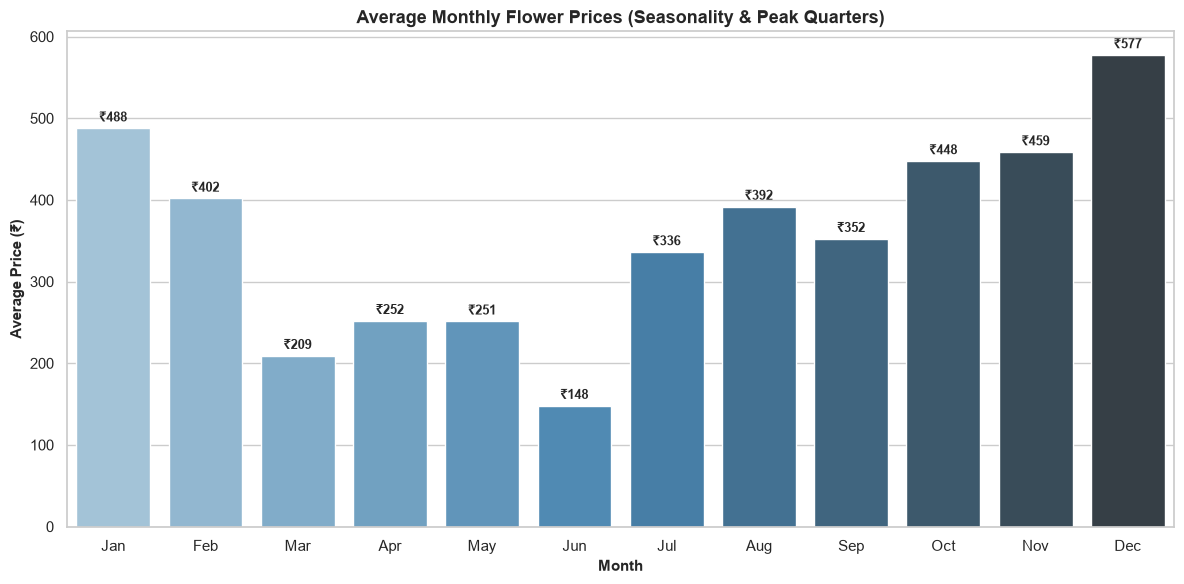

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Cleaned Dataset
CLEAN_CSV = r"C:\Project\data\processed\flower_prices_cleaned.csv"
df = pd.read_csv(CLEAN_CSV)
df['DATE'] = pd.to_datetime(df['DATE'])

# Identify appropriate price column
price_col = 'price_updated' if 'price_updated' in df.columns else ('price_cleaned' if 'price_cleaned' in df.columns else 'price')

# 2. Extract Month & Year
df['Month_Num'] = df['DATE'].dt.month
df['Month_Name'] = df['DATE'].dt.strftime('%b')
df['Year'] = df['DATE'].dt.year

# 3. Monthly Summary Statistics
monthly_stats = df.groupby(['Month_Num', 'Month_Name'])[price_col].agg(
    Mean_Price=('mean'),
    Median_Price=('median'),
    Std_Dev=('std'),
    Min_Price=('min'),
    Max_Price=('max')
).reset_index().round(2)

print("=" * 80)
print("1. MONTHLY SEASONALITY SUMMARY (2010–2016)")
print("=" * 80)
print(monthly_stats[['Month_Name', 'Mean_Price', 'Median_Price', 'Std_Dev', 'Min_Price', 'Max_Price']].to_string(index=False))

# 4. Plot Monthly Trend
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax = sns.barplot(
    data=df, 
    x='Month_Name', 
    y=price_col, 
    order=month_order, 
    palette='Blues_d', 
    errorbar=None
)

# Annotate exact price values above bars
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        ax.annotate(
            f'₹{height:.0f}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', xytext=(0, 3),
            textcoords='offset points'
        )

plt.title('Average Monthly Flower Prices (Seasonality & Peak Quarters)', fontsize=13, fontweight='bold')
plt.xlabel('Month', fontsize=11, fontweight='bold')
plt.ylabel('Average Price (₹)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

BASELINE ORDINARY DAY AVERAGE PRICE: ₹355.44

2. FESTIVAL BREAKDOWN & PERCENTAGE PRICE SURGES
     festival_clean  Days_Count  Festival_Avg_Price  Festival_Max_Price  Ordinary_Baseline_Price  Price_Jump_(₹)  Percentage_Surge_(%)
      Durga Ashtami           7              760.71               820.0                   355.44          405.27                114.02
          Christmas           7              746.43               820.0                   355.44          390.99                110.00
     Saraswati Puja           7              732.14               820.0                   355.44          376.70                105.98
           Dussehra           7              617.86               820.0                   355.44          262.41                 73.83
      Vijayadashami           7              617.86               820.0                   355.44          262.41                 73.83
   Makara Sankranti           7              572.00               820.0                   355.44

C:\Users\ASUS\AppData\Local\Temp\ipykernel_25620\2131677960.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


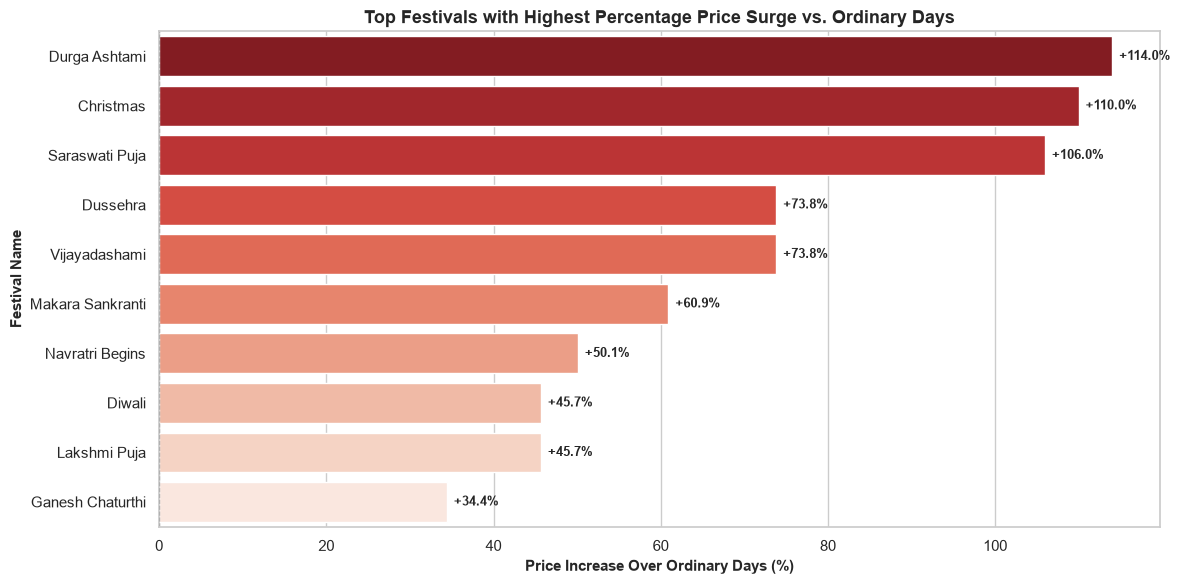

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Cleaned Dataset
CLEAN_CSV = r"C:\Project\data\processed\flower_prices_cleaned.csv"
df = pd.read_csv(CLEAN_CSV)
df['DATE'] = pd.to_datetime(df['DATE'])

price_col = 'price_updated' if 'price_updated' in df.columns else ('price_cleaned' if 'price_cleaned' in df.columns else 'price')

# 2. Calculate Baseline Ordinary Day Price
is_fest = df['festival_name'].notna() & (df['festival_name'] != '')
ordinary_baseline_price = df[~is_fest][price_col].mean()

print("=" * 80)
print(f"BASELINE ORDINARY DAY AVERAGE PRICE: ₹{ordinary_baseline_price:.2f}")
print("=" * 80)

# 3. Explode Multiple Festivals Co-occurring on the Same Day
df_festivals = df[is_fest].copy()
df_festivals['festival_list'] = df_festivals['festival_name'].astype(str).str.split('|')
df_exploded = df_festivals.explode('festival_list')
df_exploded['festival_clean'] = df_exploded['festival_list'].str.strip()

# 4. Group by Specific Festival Name
festival_breakdown = df_exploded.groupby('festival_clean')[price_col].agg(
    Days_Count='count',
    Festival_Avg_Price='mean',
    Festival_Max_Price='max'
).reset_index()

# 5. Calculate Percentage Markup over Ordinary Baseline
festival_breakdown['Ordinary_Baseline_Price'] = round(ordinary_baseline_price, 2)
festival_breakdown['Price_Jump_(₹)'] = festival_breakdown['Festival_Avg_Price'] - ordinary_baseline_price
festival_breakdown['Percentage_Surge_(%)'] = (
    (festival_breakdown['Price_Jump_(₹)'] / ordinary_baseline_price) * 100
)

# Format and sort by highest percentage surge
festival_breakdown = festival_breakdown.sort_values(by='Percentage_Surge_(%)', ascending=False).round(2)

print("\n2. FESTIVAL BREAKDOWN & PERCENTAGE PRICE SURGES")
print("=" * 80)
print(festival_breakdown.to_string(index=False))

# 6. Visualization: Top Festivals by Percentage Price Increase
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

top_festivals = festival_breakdown.head(10)

ax = sns.barplot(
    data=top_festivals,
    x='Percentage_Surge_(%)',
    y='festival_clean',
    palette='Reds_r'
)

# Annotate bars with exact percentage surge
for p in ax.patches:
    width = p.get_width()
    if not pd.isna(width) and width > 0:
        ax.annotate(
            f'+{width:.1f}%',
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', va='center',
            fontsize=9, fontweight='bold', xytext=(5, 0),
            textcoords='offset points'
        )

plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Top Festivals with Highest Percentage Price Surge vs. Ordinary Days', fontsize=13, fontweight='bold')
plt.xlabel('Price Increase Over Ordinary Days (%)', fontsize=11, fontweight='bold')
plt.ylabel('Festival Name', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()